In [5]:
#STEP 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
#STEP 2: Load Dataset

df = pd.read_csv("ad_click_dataset.csv")
df.head()

,id,full_name,age,gender,device_type,ad_position,browsing_history,time_of_day,click
0,670,User670,22.0,NaN,Desktop,Top,Shopping,Afternoon,1
1,3044,User3044,NaN,Male,Desktop,Top,NaN,NaN,1
2,5912,User5912,41.0,Non-Binary,NaN,Side,Education,Night,1
3,5418,User5418,34.0,Male,NaN,NaN,Entertainment,Evening,1
4,9452,User9452,39.0,Non-Binary,NaN,NaN,Social Media,Morning,0


In [18]:
#STEP 3: Explore Data

df.info()
df.describe()
df.columns

<class 'pandas.DataFrame'>
Index: 816 entries, 17 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                816 non-null    int64  
 1   full_name         816 non-null    str    
 2   age               816 non-null    float64
 3   gender            816 non-null    str    
 4   device_type       816 non-null    str    
 5   ad_position       816 non-null    str    
 6   browsing_history  816 non-null    str    
 7   time_of_day       816 non-null    str    
 8   click             816 non-null    int64  
dtypes: float64(1), int64(2), str(6)
memory usage: 63.8 KB


Index(['id', 'full_name', 'age', 'gender', 'device_type', 'ad_position',
       'browsing_history', 'time_of_day', 'click'],
      dtype='str')

In [11]:
#STEP 4: Handle Missing Values

df.isnull().sum()
df = df.dropna()

In [19]:
print(df.columns)
df.columns = df.columns.str.strip()


Index(['id', 'full_name', 'age', 'gender', 'device_type', 'ad_position',
       'browsing_history', 'time_of_day', 'click'],
      dtype='str')


In [15]:
for col in df.columns:
    print(col)

id
full_name
age
gender
device_type
ad_position
browsing_history
time_of_day
click


In [16]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['id', 'full_name', 'age', 'gender', 'device_type', 'ad_position',
       'browsing_history', 'time_of_day', 'click'],
      dtype='str')


In [20]:
target = df.columns[-1]
print("Target column is:", target)

Target column is: click


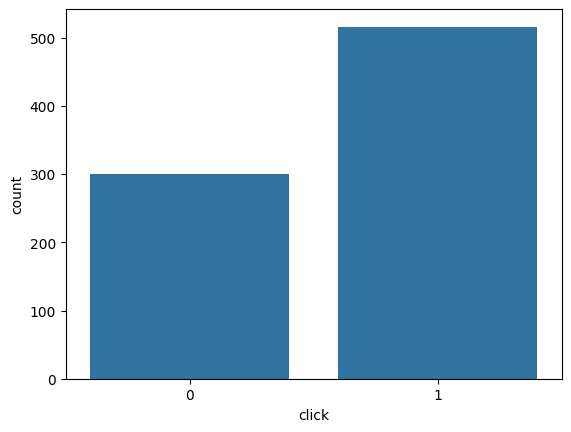

In [21]:
sns.countplot(x=target, data=df)
plt.show()

In [22]:
df = pd.get_dummies(df, drop_first=True)


In [23]:
X = df.drop(target, axis=1)
y = df[target]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)   # fit only on train
X_test = scaler.transform(X_test)         # apply same scaling

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))

Logistic Regression: 0.6585365853658537


In [36]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=8, min_samples_split=10)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree:", accuracy_score(y_test, y_pred_dt))

Decision Tree: 0.6463414634146342


In [38]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Random Forest:", accuracy_score(y_test, y_pred_rf))

Random Forest: 0.7378048780487805


final output

In [39]:
print("\nFinal Comparison:")
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))


Final Comparison:
Logistic Regression: 0.6585365853658537
Decision Tree: 0.6463414634146342
Random Forest: 0.7378048780487805
